In [1]:
#Import packages
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal, gaussian_kde
from scipy.interpolate import interp1d
from scipy.stats import norm

Sample mean      = -0.0346
Normal (Wald) CI = [-0.4217, 0.3526]
Percentile CI    = [-0.3871, 0.3649]


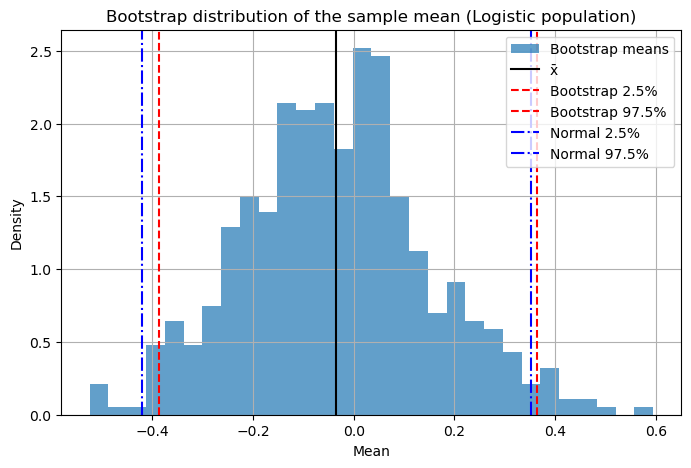

In [3]:
# BOOTSTRAP_LOGISTIC_MEAN_AND_CI.py
# Bootstrap CIs for the mean under a Logistic(mu, s) population.
# Compares Normal (Fisher-info) CI vs Percentile Bootstrap CI.


# --- Reproducibility ---
np.random.seed(0)

# --- Population (for simulation) ---
mu = 0
s = 1               # Logistic location & scale
n = 80              # sample size

# Generate logistic sample using inverse CDF method
u = np.random.rand(n)
X = mu + s * np.log(u / (1 - u))

# --- Point estimate and asymptotic (normal) CI using Var = (pi^2 s^2)/3 ---
xbar = np.mean(X)
s_hat = np.sqrt(np.var(X, ddof=1) * 3 / np.pi**2)  # plug-in estimate for logistic scale
z = 1.96
ci_norm = [
    xbar - z * np.sqrt((np.pi**2 * s_hat**2) / (3 * n)),
    xbar + z * np.sqrt((np.pi**2 * s_hat**2) / (3 * n))
]

# --- Bootstrap percentile CI ---
B = 500
boot_means = np.zeros(B)
for b in range(B):
    Xb = np.random.choice(X, size=n, replace=True)
    boot_means[b] = np.mean(Xb)

ci_pct = np.quantile(boot_means, [0.025, 0.975])

# --- Display ---
print(f"Sample mean      = {xbar:.4f}")
print(f"Normal (Wald) CI = [{ci_norm[0]:.4f}, {ci_norm[1]:.4f}]")
print(f"Percentile CI    = [{ci_pct[0]:.4f}, {ci_pct[1]:.4f}]")

# --- Plot ---
plt.figure(figsize=(8,5), facecolor='w')
plt.hist(boot_means, bins=30, density=True, alpha=0.7, edgecolor='none', label='Bootstrap means')

plt.axvline(xbar, color='k', linestyle='-', linewidth=1.5, label='x̄')
plt.axvline(ci_pct[0], color='r', linestyle='--', linewidth=1.5, label='Bootstrap 2.5%')
plt.axvline(ci_pct[1], color='r', linestyle='--', linewidth=1.5, label='Bootstrap 97.5%')
plt.axvline(ci_norm[0], color='b', linestyle='-.', linewidth=1.5, label='Normal 2.5%')
plt.axvline(ci_norm[1], color='b', linestyle='-.', linewidth=1.5, label='Normal 97.5%')

plt.title('Bootstrap distribution of the sample mean (Logistic population)')
plt.xlabel('Mean')
plt.ylabel('Density')
plt.legend(loc='best')
plt.grid(True)
plt.show()


In [5]:
# BOOTSTRAP_CORRELATION_MATRIX_SLICE.py
# Bootstrap the full dxd correlation matrix from a dataset,
# then slice-sample the marginal density of a chosen correlation r_{j,k}.
# ---------------------------------------------------------------
# Helper: Univariate slice sampler
# ---------------------------------------------------------------
def slice1d(logpdf, x0, w, max_steps, N, bounds):
    """
    Univariate slice sampling.
    Args:
        logpdf: function returning log density
        x0: initial value
        w: step-out window
        max_steps: max step-out steps
        N: number of samples
        bounds: (low, high)
    """
    samples = np.zeros(N)
    x = x0
    low, high = bounds

    for i in range(N):
        # Evaluate logpdf at current position
        fx = logpdf(x)
        # Draw vertical level uniformly from (0, f(x))
        u = np.random.rand()
        y = fx - np.log(u)  # log-space equivalent

        # Step out
        L = x - w * np.random.rand()
        R = L + w
        j = int(np.floor(max_steps * np.random.rand()))
        k = (max_steps - 1) - j

        while j > 0 and L > low and logpdf(L) > y:
            L -= w
            j -= 1
        while k > 0 and R < high and logpdf(R) > y:
            R += w
            k -= 1

        # Shrinkage loop
        while True:
            x_new = np.random.uniform(L, R)
            if logpdf(x_new) > y:
                x = x_new
                break
            elif x_new < x:
                L = x_new
            else:
                R = x_new

        samples[i] = x

    return samples

In [7]:
# ---------------------------------------------------------------
# Simulated data (replace with real data)
# ---------------------------------------------------------------
np.random.seed(0)
n = 100
d = 5
rho = 0.7

# AR(1)-like correlation matrix
Sigma = rho ** np.abs(np.subtract.outer(np.arange(d), np.arange(d)))
X = np.random.multivariate_normal(np.zeros(d), Sigma, size=n)

# ---------------------------------------------------------------
# Bootstrap correlation matrices
# ---------------------------------------------------------------
B = 100
p = d * (d - 1) // 2
Rvec = np.zeros((B, p))

inds = np.triu_indices(d, k=1)

for b in range(B):
    idx = np.random.randint(0, n, n)
    Xb = X[idx, :]
    Rb = np.corrcoef(Xb, rowvar=False)
    Rvec[b, :] = Rb[inds]


In [9]:
# ---------------------------------------------------------------
# Choose a pair (j, k)
# ---------------------------------------------------------------
j, k = 1, 3  # MATLAB indices (1-based)
j -= 1
k -= 1

# Map (j, k) to column in Rvec
colmap = np.zeros((d, d), dtype=int)
colmap[inds] = np.arange(p)
col = colmap[j, k]
r_boot = Rvec[:, col]

# ---------------------------------------------------------------
# Fisher-z CI (analytic)
# ---------------------------------------------------------------
z = 0.5 * np.log((1 + r_boot) / (1 - r_boot))
z_mean = np.mean(z)
z_se = 1 / np.sqrt(n - 3)
z_ci = [z_mean - 1.96 * z_se, z_mean + 1.96 * z_se]
ci_fisher = (np.exp(2 * np.array(z_ci)) - 1) / (np.exp(2 * np.array(z_ci)) + 1)

# ---------------------------------------------------------------
# KDE estimate of marginal pdf over (-1, 1)
# ---------------------------------------------------------------
grid_r = np.linspace(-0.999, 0.999, 1000)
kde = gaussian_kde(r_boot)
kde_pdf = kde(grid_r)
pdf_fun = interp1d(grid_r, kde_pdf, kind='linear', bounds_error=False, fill_value=0.0)


In [11]:
# ---------------------------------------------------------------
# Slice sampling over r in (-1,1)
# ---------------------------------------------------------------
Ns = 100
burn = 50
r0 = np.median(r_boot)

def logpdf(r):
    val = pdf_fun(r)
    return np.log(np.maximum(val, np.finfo(float).tiny))

samples = slice1d(logpdf, r0, w=0.05, max_steps=50, N=Ns + burn, bounds=(-0.999, 0.999))
r_slice = samples[burn:]

KeyboardInterrupt: 

In [ ]:
# ---------------------------------------------------------------
# Intervals
# ---------------------------------------------------------------
ci_boot = np.quantile(r_boot, [0.025, 0.975])
ci_slice = np.quantile(r_slice, [0.025, 0.975])

print(f"Correlation r_{{{j+1},{k+1}}}")
print(f"Bootstrap percentile CI : [{ci_boot[0]:.3f}, {ci_boot[1]:.3f}]")
print(f"Fisher-z CI (analytic)  : [{ci_fisher[0]:.3f}, {ci_fisher[1]:.3f}]")
print(f"Slice-sampled CI        : [{ci_slice[0]:.3f}, {ci_slice[1]:.3f}]")

# ---------------------------------------------------------------
# Plots
# ---------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(10, 4), facecolor='w')

# Left: bootstrap histogram
ax = axes[0]
ax.hist(r_boot, bins=30, density=True, alpha=0.7, edgecolor='none')
ax.axvline(ci_boot[0], color='r', linestyle='--', linewidth=1.4, label='Boot 2.5%')
ax.axvline(ci_boot[1], color='r', linestyle='--', linewidth=1.4, label='Boot 97.5%')
ax.axvline(ci_fisher[0], color='b', linestyle='-.', linewidth=1.4, label='Fisher-z 2.5%')
ax.axvline(ci_fisher[1], color='b', linestyle='-.', linewidth=1.4, label='Fisher-z 97.5%')
ax.set_xlabel(f"r_{{{j+1},{k+1}}}")
ax.set_ylabel("Density")
ax.set_title("Bootstrap distribution of r and analytic Fisher-z CI")
ax.legend()
ax.grid(True)

# Right: slice-sampled marginal
ax = axes[1]
ax.hist(r_slice, bins=30, density=True, alpha=0.7, edgecolor='none')
ax.axvline(ci_slice[0], color='m', linestyle='--', linewidth=1.4, label='Slice 2.5%')
ax.axvline(ci_slice[1], color='m', linestyle='--', linewidth=1.4, label='Slice 97.5%')
ax.set_xlabel(f"r_{{{j+1},{k+1}}}")
ax.set_ylabel("Density")
ax.set_title("Slice-sampled marginal for r")
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()


In [ ]:
# Plot_Logistic_Distribution.py
# Visualization of the Logistic distribution for various (mu, s)
# STAT THEORY & COMPUTATION — Project Exercise
# --------------------------------------------------------------

# x-grid for plotting
x = np.linspace(-8, 8, 400)

# Parameter sets
mu_vals = [0, 0, 0, -2, 0, 2]     # vary both location & scale
s_vals  = [0.5, 1, 2,  1,  1, 1]  # first 3: vary scale, last 3: vary location
colors = plt.cm.tab10(np.linspace(0, 1, len(mu_vals)))

plt.figure(figsize=(8, 5), facecolor='w')
plt.grid(True)
plt.box(True)

# Plot logistic pdfs
for i, (mu, s) in enumerate(zip(mu_vals, s_vals)):
    fx = np.exp(-(x - mu) / s) / (s * (1 + np.exp(-(x - mu) / s))**2)
    plt.plot(
        x, fx, linewidth=2, color=colors[i],
        label=fr'$\mu={mu:.1f},\ s={s:.1f}$'
    )

# Overlay standard normal for comparison
fx_norm = norm.pdf(x, 0, 1)
plt.plot(x, fx_norm, 'k--', linewidth=1.5, label='Normal(0,1)')

# Labels and formatting
plt.xlabel(r'$x$')
plt.ylabel(r'$f(x|\mu,s)$')
plt.title('Logistic Distribution for Different Location and Scale Parameters')
plt.legend(loc='upper right')
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()


In [ ]:
def slice1d(logpdf, x0, w, max_steps, N, bounds):
    """
    Simple univariate slice sampler with stepping-out and shrinkage.
    
    Parameters
    ----------
    logpdf : callable
        Function returning log-density (unnormalized).
    x0 : float
        Starting point (must lie within bounds).
    w : float
        Initial bracket width.
    max_steps : int
        Maximum number of step-out iterations.
    N : int
        Number of samples to draw.
    bounds : tuple (L, U)
        Lower and upper bounds of the support.
    
    Returns
    -------
    samples : ndarray
        Array of N sampled values.
    """
    L, U = bounds
    samples = np.zeros(N)
    x = np.clip(x0, L, U)  # ensure starting point is inside bounds

    for t in range(N):
        # vertical level
        logy = logpdf(x) + np.log(np.random.rand())

        # create initial interval [a, b] around x
        u = np.random.rand() * w
        a = x - u
        b = x + (w - u)

        # step-out procedure
        j = int(np.floor(np.random.rand() * max_steps))
        k = (max_steps - 1) - j

        while j > 0 and a > L and logpdf(a) > logy:
            a = max(a - w, L)
            j -= 1

        while k > 0 and b < U and logpdf(b) > logy:
            b = min(b + w, U)
            k -= 1

        # shrinkage loop
        while True:
            x_new = a + np.random.rand() * (b - a)
            if logpdf(x_new) >= logy:
                x = x_new
                break
            elif x_new < x:
                a = x_new
            else:
                b = x_new

        samples[t] = x

    return samples
